<a href="https://colab.research.google.com/github/peachonali/Course-AI-and-Machine-Learning/blob/main/Week10_LAB6_1D%20Linear%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. ให้นักศึกษาเขียนโปรแกรมภาษา Python เพื่อแก้ปัญหา 1D Linear Regression ด้วย Gradient Decent และแสดงผลการทำงานของโปรแกรมบนหน้าจอ ดังต่อไปนี้

Initial Cost (before GD): 0.9000
Initial Theta0: 0.0000, Initial Theta1: 1.0000

Iteration 1: Cost = 0.6532, Theta0 = 0.1000, Theta1 = 1.2200
Iteration 2: Cost = 0.6318, Theta0 = 0.1240, Theta1 = 1.1680
Iteration 3: Cost = 0.6184, Theta0 = 0.1612, Theta1 = 1.1660
Iteration 4: Cost = 0.6057, Theta0 = 0.1953, Theta1 = 1.1550
Iteration 5: Cost = 0.5935, Theta0 = 0.2292, Theta1 = 1.1459
Converged at iteration 282!

--- Final Results ---
Final Theta0: 2.1825
Final Theta1: 0.6049
Final Minimum Cost: 0.2400


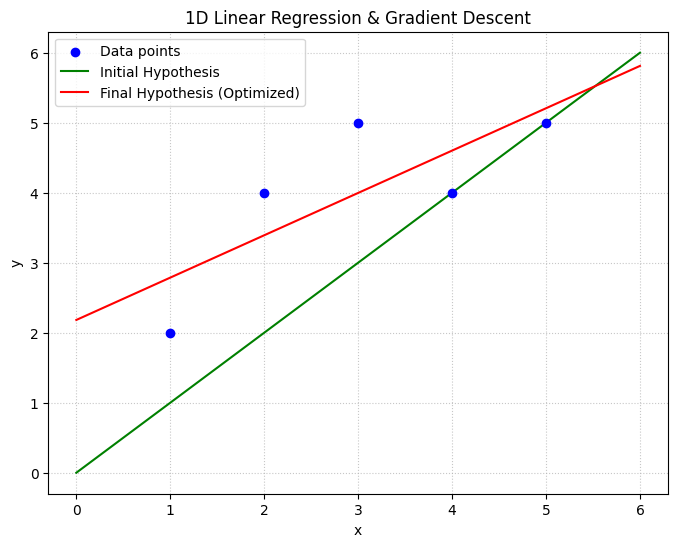

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])

theta0 = 0.0
theta1 = 1.0

alpha = 0.1      # Learning rate (set to 0.05 for stable convergence)
max_iter = 1000  # Maximum number of iterations (not exceeding 1000 rounds)
tolerance = 0.000001  # Convergence criteria (stop if cost decreases less than this)

def compute_cost(t0, t1, x, y):
    m = len(x)
    predictions = t0 + t1 * x
    # Calculate cost (Mean Squared Error)
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

# Calculate initial cost before doing Gradient Descent
initial_cost = compute_cost(theta0, theta1, x, y)
print(f"Initial Cost (before GD): {initial_cost:.4f}")
print(f"Initial Theta0: {theta0:.4f}, Initial Theta1: {theta1:.4f}\n")

# Keep track of initial thetas to plot the starting hypothesis later
initial_theta0 = theta0
initial_theta1 = theta1

# Store cost history to track the decrease cost ทุกการวนซ้ำ
cost_history = [initial_cost]

# Perform Gradient Descent until convergence or max 1000 iterations
m = len(x)
for i in range(max_iter):
    predictions = theta0 + theta1 * x

    # Calculate errors and gradients
    error = predictions - y
    grad0 = (1 / m) * np.sum(error)
    grad1 = (1 / m) * np.sum(error * x)

    # Update thetas simultaneously
    theta0 = theta0 - alpha * grad0 # จุด error ที่ได้ คูณ เอ่าฟ่า เก็บใน เซต้า0
    theta1 = theta1 - alpha * grad1

    # Compute new cost for the current iteration
    current_cost = compute_cost(theta0, theta1, x, y)
    cost_history.append(current_cost)

    # Optional: Print cost for the first few iterations to show the process
    if i < 5:
        print(f"Iteration {i+1}: Cost = {current_cost:.4f}, Theta0 = {theta0:.4f}, Theta1 = {theta1:.4f}")

    # Check for convergence (stop if cost is minimized and barely changing)
    if abs(cost_history[-2] - current_cost) < tolerance:
        print(f"Converged at iteration {i+1}!")
        break

# Display final Theta0 and Theta1
print(f"\n--- Final Results ---")
print(f"Final Theta0: {theta0:.4f}")
print(f"Final Theta1: {theta1:.4f}")
print(f"Final Minimum Cost: {cost_history[-1]:.4f}")

# Setup the plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', label='Data points', zorder=5)
x_line = np.linspace(0, 6, 100)
plt.plot(x_line, initial_theta0 + initial_theta1 * x_line,
         color='green', label='Initial Hypothesis')
plt.plot(x_line, theta0 + theta1 * x_line,
         color='red', label='Final Hypothesis (Optimized)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('1D Linear Regression & Gradient Descent')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

#2. จากโปรแกรมในข้อ 1 ให้ นศ ปรับปรุงโปรแกรมดังกล่าวให้สร้างชุดข้อมูลเริ่มต้นจำนวน 1,000 ชุดแบบสุ่ม โดยใช้คำสั่ง

from sklearn import datasets

load dataset

x, y = datasets.make_regression(n_samples=1000, n_features=1, noise=20, random_state=1)


นศ. สามารถดูตัวอย่างการใช้งาน Scikit Learn ในการสร้างชุดตัวอย่างข้อมูลได้จาก

* >> Implementing
Linear Regression with Gradient Descent From Scratch

Initial Cost (before GD): 870.7976
Initial Theta0: 0.0000, Initial Theta1: 1.0000

Iteration 1: Cost = 747.5310, Theta0 = 0.2027, Theta1 = 4.5934
Iteration 2: Cost = 646.9777, Theta0 = 0.3712, Theta1 = 7.8397
Iteration 3: Cost = 564.9459, Theta0 = 0.5102, Theta1 = 10.7724
Iteration 4: Cost = 498.0187, Theta0 = 0.6240, Theta1 = 13.4220
Iteration 5: Cost = 443.4106, Theta0 = 0.7161, Theta1 = 15.8157
Converged at iteration 94!

--- Final Results ---
Final Theta0: 0.5819
Final Theta1: 38.2548
Final Minimum Cost: 200.7931


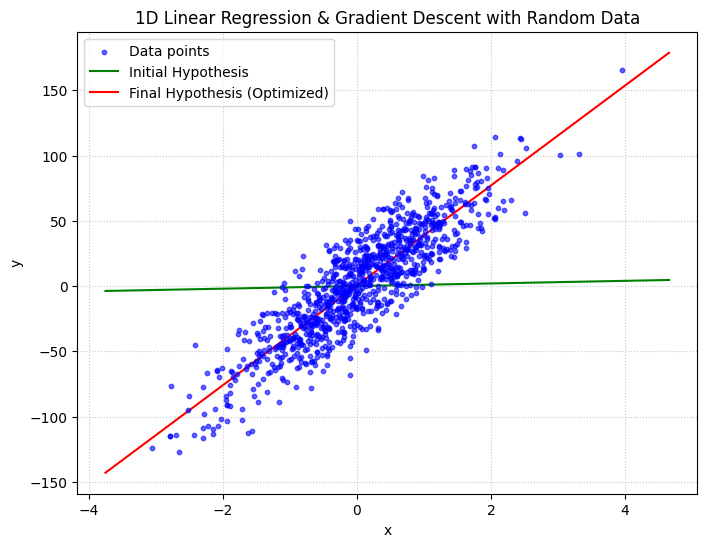

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

# ***Generate random data instead of hardcoding
x, y = datasets.make_regression(n_samples=1000, n_features=1, noise=20, random_state=1)
x = x.flatten() # Flatten x from (1000, 1) to (1000,)

theta0 = 0.0
theta1 = 1.0

alpha = 0.1      # Learning rate (adjusted to a smaller value for potentially larger datasets)
max_iter = 1000  # Maximum number of iterations (increased for potentially more complex data)
tolerance = 1e-6  # Convergence criteria (stop if cost decreases less than this)

def compute_cost(t0, t1, x, y):
    m = len(x)
    predictions = t0 + t1 * x
    # Calculate cost (Mean Squared Error)
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

# Calculate initial cost before doing Gradient Descent
initial_cost = compute_cost(theta0, theta1, x, y)
print(f"Initial Cost (before GD): {initial_cost:.4f}")
print(f"Initial Theta0: {theta0:.4f}, Initial Theta1: {theta1:.4f}\n")

# Keep track of initial thetas to plot the starting hypothesis later
initial_theta0 = theta0
initial_theta1 = theta1

# Store cost history to track the decrease
cost_history = [initial_cost]

# Perform Gradient Descent until convergence or max iterations
m = len(x)
for i in range(max_iter):
    predictions = theta0 + theta1 * x

    # Calculate errors and gradients
    error = predictions - y
    grad0 = (1 / m) * np.sum(error)
    grad1 = (1 / m) * np.sum(error * x)

    # Update thetas simultaneously
    theta0 = theta0 - alpha * grad0
    theta1 = theta1 - alpha * grad1

    # Compute new cost for the current iteration
    current_cost = compute_cost(theta0, theta1, x, y)
    cost_history.append(current_cost)

    # ***Optional: Print cost for the first few iterations to show the process
    if i < 5 or (i % 1000 == 0 and i > 0):
        print(f"Iteration {i+1}: Cost = {current_cost:.4f}, Theta0 = {theta0:.4f}, Theta1 = {theta1:.4f}")

    # ***Check for convergence (stop if cost is minimized and barely changing)
    if len(cost_history) > 1 and abs(cost_history[-2] - current_cost) < tolerance:
        print(f"Converged at iteration {i+1}!")
        break

# Display final Theta0 and Theta1
print(f"\n--- Final Results ---")
print(f"Final Theta0: {theta0:.4f}")
print(f"Final Theta1: {theta1:.4f}")
print(f"Final Minimum Cost: {cost_history[-1]:.4f}")

# Setup the plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', label='Data points', zorder=5, alpha=0.6, s=10)
# ***Adjust x_line to cover the range of the newly generated x data, with some padding
x_line = np.linspace(x.min() - (x.max() - x.min())*0.1, x.max() + (x.max() - x.min())*0.1, 100)
plt.plot(x_line, initial_theta0 + initial_theta1 * x_line,
         color='green', label='Initial Hypothesis')
plt.plot(x_line, theta0 + theta1 * x_line,
         color='red', label='Final Hypothesis (Optimized)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('1D Linear Regression & Gradient Descent with Random Data')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

#3. จากโปรแกรมในข้อ 2 ให้ นศ ปรับปรุงโปรแกรมดังกล่าวโดยใช้ Library สำเร็จรูปจาก Scikit Learn โดยเปลี่ยนจากการใช้ Gradient Decent เป็นการใช้ Ordinary Least Squares (OLS) และ Stochastic Gradient Descent (SGD) ตามลำดับ เพื่อเปรียบเทียบการทำงานระหว่างทั้ง 3 algorithm ในเรื่องเวลา ในการทำงานและผลลัพธ์สุดท้ายที่ได้


นศ. สามารถดูตัวอย่างการใช้งาน Scikit Learn ในการทำ Linear Regression โดยใช้ OLS และ SGD ได้
จาก

* >>  SDGRegressor vs LinearRegression

--- Ordinary Least Squares (OLS) ---
OLS Theta0: 0.5810
OLS Theta1: 38.2577
OLS Execution Time: 0.008563 seconds

Initial Cost (before Manual GD): 870.7976
Initial Theta0 (Manual GD): 0.0000, Initial Theta1 (Manual GD): 1.0000

--- Manual Gradient Descent ---
Iteration 1: Cost = 747.5310, Theta0 = 0.2027, Theta1 = 4.5934
Iteration 2: Cost = 646.9777, Theta0 = 0.3712, Theta1 = 7.8397
Iteration 3: Cost = 564.9459, Theta0 = 0.5102, Theta1 = 10.7724
Iteration 4: Cost = 498.0187, Theta0 = 0.6240, Theta1 = 13.4220
Iteration 5: Cost = 443.4106, Theta0 = 0.7161, Theta1 = 15.8157
Converged at iteration 94!

--- Final Results (Manual GD) ---
Final Theta0: 0.5819
Final Theta1: 38.2548
Final Minimum Cost: 200.7931
Manual GD Execution Time: 0.012370 seconds

--- SGDRegressor (Stochastic Gradient Descent) ---
SGD Theta0: 0.7021
SGD Theta1: 38.6738
SGD Execution Time: 0.003898 seconds

--- Algorithm Comparison ---
Algorithm            | Theta0     | Theta1     | Min Cost     | Iterations   | Time (s)

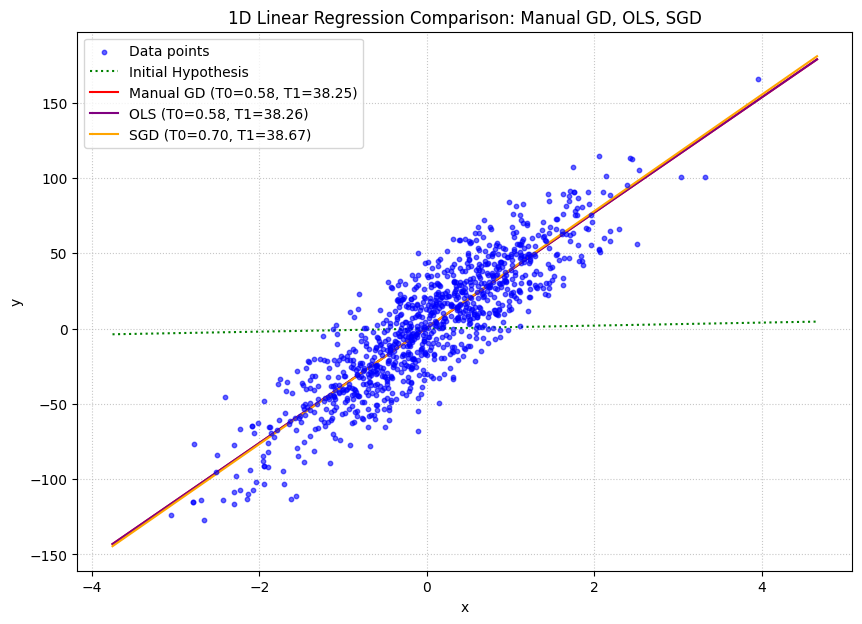

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.linear_model import LinearRegression, SGDRegressor
import time

# Generate random data instead of hardcoding
x, y = datasets.make_regression(n_samples=1000, n_features=1, noise=20, random_state=1)
x = x.flatten() # Flatten x from (1000, 1) to (1000,)

# Reshape x for sklearn models (expects 2D array for features)
X_reshaped = x.reshape(-1, 1)


# --- Ordinary Least Squares (OLS) ---
print("--- Ordinary Least Squares (OLS) ---")
start_time_ols = time.time()
ols_model = LinearRegression()
ols_model.fit(X_reshaped, y)
end_time_ols = time.time()
ols_execution_time = end_time_ols - start_time_ols

theta0_ols = ols_model.intercept_
theta1_ols = ols_model.coef_[0]

print(f"OLS Theta0: {theta0_ols:.4f}")
print(f"OLS Theta1: {theta1_ols:.4f}")
print(f"OLS Execution Time: {ols_execution_time:.6f} seconds\n")

# --- Manual Gradient Descent (GD) ---

theta0_gd = 0.0 # Use theta0_gd and theta1_gd to avoid conflict with OLS/SGD variables
theta1_gd = 1.0

alpha = 0.1      # Learning rate (adjusted to a smaller value for potentially larger datasets)
max_iter = 1000  # Maximum number of iterations (increased for potentially more complex data)
tolerance = 1e-6  # Convergence criteria (stop if cost decreases less than this)

def compute_cost(t0, t1, x, y):
    m = len(x)
    predictions = t0 + t1 * x
    # Calculate cost (Mean Squared Error)
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

# Calculate initial cost before doing Gradient Descent
initial_cost = compute_cost(theta0_gd, theta1_gd, x, y)
print(f"Initial Cost (before Manual GD): {initial_cost:.4f}")
print(f"Initial Theta0 (Manual GD): {theta0_gd:.4f}, Initial Theta1 (Manual GD): {theta1_gd:.4f}")
print("======================================================================\n")

# Keep track of initial thetas to plot the starting hypothesis later
initial_theta0 = theta0_gd # Renaming to initial_theta0 for plotting
initial_theta1 = theta1_gd # Renaming to initial_theta1 for plotting

# Store cost history to track the decrease
cost_history = [initial_cost]

# Perform Gradient Descent until convergence or max iterations
m = len(x)

print("--- Manual Gradient Descent ---")
start_time_gd = time.time()
for i in range(max_iter):
    predictions = theta0_gd + theta1_gd * x

    # Calculate errors and gradients
    error = predictions - y
    grad0 = (1 / m) * np.sum(error)
    grad1 = (1 / m) * np.sum(error * x)

    # Update thetas simultaneously
    theta0_gd = theta0_gd - alpha * grad0
    theta1_gd = theta1_gd - alpha * grad1

    # Compute new cost for the current iteration
    current_cost = compute_cost(theta0_gd, theta1_gd, x, y)
    cost_history.append(current_cost)

    # Optional: Print cost for the first few iterations to show the process
    if i < 5 or (i % 1000 == 0 and i > 0 and current_cost > cost_history[-2]): # Only print if not converged yet
        print(f"Iteration {i+1}: Cost = {current_cost:.4f}, Theta0 = {theta0_gd:.4f}, Theta1 = {theta1_gd:.4f}")

    # Check for convergence (stop if cost is minimized and barely changing)
    if len(cost_history) > 1 and abs(cost_history[-2] - current_cost) < tolerance:
        print(f"Converged at iteration {i+1}!")
        break
end_time_gd = time.time()
gd_execution_time = end_time_gd - start_time_gd

# Display final Theta0 and Theta1
print(f"\n--- Final Results (Manual GD) ---")
print(f"Final Theta0: {theta0_gd:.4f}")
print(f"Final Theta1: {theta1_gd:.4f}")
print(f"Final Minimum Cost: {cost_history[-1]:.4f}")
print(f"Manual GD Execution Time: {gd_execution_time:.6f} seconds")
print("======================================================================\n")

# --- SGDRegressor (Stochastic Gradient Descent) ---
print("--- SGDRegressor (Stochastic Gradient Descent) ---")
start_time_sgd = time.time()
# SGDRegressor expects y to be 1D, which it already is.
sgd_model = SGDRegressor(max_iter=max_iter, eta0=alpha, random_state=1, tol=tolerance)
sgd_model.fit(X_reshaped, y)
end_time_sgd = time.time()
sgd_execution_time = end_time_sgd - start_time_sgd

theta0_sgd = sgd_model.intercept_[0] # Intercept is an array for SGDRegressor
theta1_sgd = sgd_model.coef_[0]

print(f"SGD Theta0: {theta0_sgd:.4f}")
print(f"SGD Theta1: {theta1_sgd:.4f}")
print(f"SGD Execution Time: {sgd_execution_time:.6f} seconds")


gd_iterations = i + 1
sgd_iterations = sgd_model.n_iter_

# Calculate final costs for OLS and SGD using the compute_cost function
ols_final_cost = compute_cost(theta0_ols, theta1_ols, x, y)
sgd_final_cost = compute_cost(theta0_sgd, theta1_sgd, x, y)

print("======================================================================")
print("\n--- Algorithm Comparison ---")
print(f"{"Algorithm":<20} | {"Theta0":<10} | {"Theta1":<10} | {"Min Cost":<12} | {"Iterations":<12} | {"Time (s)":<12}")
print("-" * 90)
print(f"{"OLS":<20} | {theta0_ols:<10.4f} | {theta1_ols:<10.4f} | {ols_final_cost:<12.4f} | {"N/A":<12} | {ols_execution_time:<12.6f}")
print(f"{"Manual GD":<20} | {theta0_gd:<10.4f} | {theta1_gd:<10.4f} | {cost_history[-1]:<12.4f} | {gd_iterations:<12} | {gd_execution_time:<12.6f}")
print(f"{"SGD":<20} | {theta0_sgd:<10.4f} | {theta1_sgd:<10.4f} | {sgd_final_cost:<12.4f} | {sgd_iterations:<12} | {sgd_execution_time:<12.6f}")
print("\n")

# --- Plotting ---
# Setup the plot
plt.figure(figsize=(10, 7))
plt.scatter(x, y, color='blue', label='Data points', zorder=5, alpha=0.6, s=10)

x_line = np.linspace(x.min() - (x.max() - x.min())*0.1, x.max() + (x.max() - x.min())*0.1, 100)

plt.plot(x_line, initial_theta0 + initial_theta1 * x_line,
         color='green', linestyle=':', label='Initial Hypothesis')
plt.plot(x_line, theta0_gd + theta1_gd * x_line,
         color='red', label=f'Manual GD (T0={theta0_gd:.2f}, T1={theta1_gd:.2f})')
plt.plot(x_line, theta0_ols + theta1_ols * x_line,
         color='purple', label=f'OLS (T0={theta0_ols:.2f}, T1={theta1_ols:.2f})')
plt.plot(x_line, theta0_sgd + theta1_sgd * x_line,
         color='orange', label=f'SGD (T0={theta0_sgd:.2f}, T1={theta1_sgd:.2f})')

plt.xlabel('x')
plt.ylabel('y')
plt.title('1D Linear Regression Comparison: Manual GD, OLS, SGD')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

#เพิ่ม X เป็น 2D มิติ

Initial Cost (before GD): 2886.6037
Initial Theta0: 0.0000, Initial Theta1: 1.0000, Initial Theta2: 0.5000

Iteration 1: Cost = 2476.1989, Theta0 = 1.9296, Theta1 = 2.6648, Theta2 = 6.5361
Iteration 2: Cost = 2134.2824, Theta0 = 3.5317, Theta1 = 4.2550, Theta2 = 12.0715
Iteration 3: Cost = 1848.4426, Theta0 = 4.8502, Theta1 = 5.7709, Theta2 = 17.1523
Iteration 4: Cost = 1608.6713, Theta0 = 5.9237, Theta1 = 7.2133, Theta2 = 21.8200
Iteration 5: Cost = 1406.8759, Theta0 = 6.7859, Theta1 = 8.5836, Theta2 = 26.1117
Converged at iteration 153!

--- Final Results ---
Final Theta0: 1.4630
Final Theta1: 30.3486
Final Theta2: 80.9049
Final Minimum Cost: 201.4131


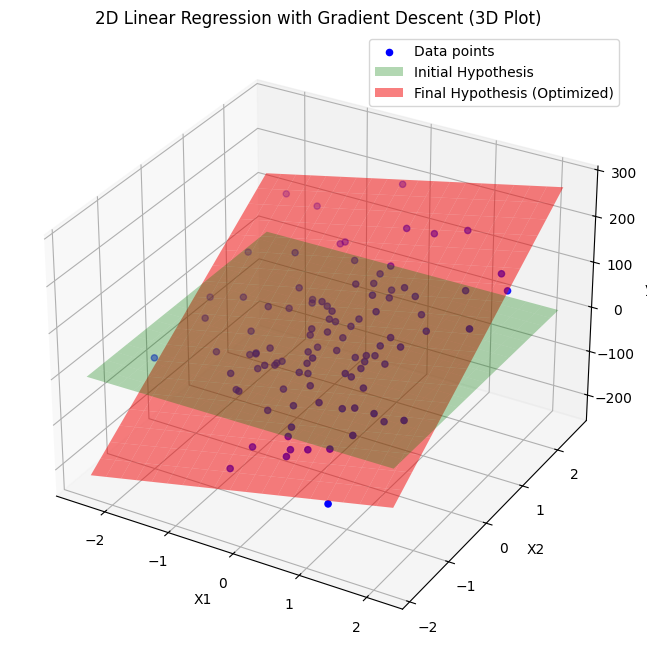

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets # Import datasets for data generation
from mpl_toolkits.mplot3d import Axes3D # For 3D plotting

# Generate 2D random data
X, y = datasets.make_regression(n_samples=100, n_features=2, noise=20, random_state=1)
# Ensure y is 1D if make_regression returns (n_samples,) - it usually does for single target
if y.ndim > 1:
    y = y.flatten()

# Initialize parameters for 2D linear regression: theta0 (intercept), theta1 (coef for X1), theta2 (coef for X2)
theta0 = 0.0
theta1 = 1.0
theta2 = 0.5 # New parameter for the second feature

alpha = 0.1      # Learning rate
max_iter = 1000  # Maximum number of iterations
tolerance = 0.000001  # Convergence criteria

def compute_cost(t0, t1, t2, X, y): # Added t2 parameter
    m = len(y)
    predictions = t0 + t1 * X[:, 0] + t2 * X[:, 1] # Use both features
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

# Calculate initial cost
initial_cost = compute_cost(theta0, theta1, theta2, X, y) # Pass theta2
print(f"Initial Cost (before GD): {initial_cost:.4f}")
print(f"Initial Theta0: {theta0:.4f}, Initial Theta1: {theta1:.4f}, Initial Theta2: {theta2:.4f}\n") # Print theta2

# Keep track of initial thetas for plotting
initial_theta0 = theta0
initial_theta1 = theta1
initial_theta2 = theta2 # Store initial theta2

cost_history = [initial_cost]

m = len(y)
for i in range(max_iter):
    predictions = theta0 + theta1 * X[:, 0] + theta2 * X[:, 1] # Use both features

    error = predictions - y
    grad0 = (1 / m) * np.sum(error)
    grad1 = (1 / m) * np.sum(error * X[:, 0]) # Gradient for X1
    grad2 = (1 / m) * np.sum(error * X[:, 1]) # Gradient for X2

    theta0 = theta0 - alpha * grad0
    theta1 = theta1 - alpha * grad1
    theta2 = theta2 - alpha * grad2 # Update theta2

    current_cost = compute_cost(theta0, theta1, theta2, X, y) # Pass theta2
    cost_history.append(current_cost)

    if i < 5:
        print(f"Iteration {i+1}: Cost = {current_cost:.4f}, Theta0 = {theta0:.4f}, Theta1 = {theta1:.4f}, Theta2 = {theta2:.4f}") # Print theta2

    if abs(cost_history[-2] - current_cost) < tolerance:
        print(f"Converged at iteration {i+1}!")
        break

print(f"\n--- Final Results ---")
print(f"Final Theta0: {theta0:.4f}")
print(f"Final Theta1: {theta1:.4f}")
print(f"Final Theta2: {theta2:.4f}") # Print final theta2
print(f"Final Minimum Cost: {cost_history[-1]:.4f}")

# --- Plotting in 3D ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot data points
ax.scatter(X[:, 0], X[:, 1], y, color='blue', label='Data points')

# Create a meshgrid for the regression plane
x1_min, x1_max = X[:, 0].min(), X[:, 0].max()
x2_min, x2_max = X[:, 1].min(), X[:, 1].max()

x1_surf = np.linspace(x1_min, x1_max, 20)
x2_surf = np.linspace(x2_min, x2_max, 20)
x1_surf, x2_surf = np.meshgrid(x1_surf, x2_surf)

# Plot initial hypothesis plane
y_initial_surf = initial_theta0 + initial_theta1 * x1_surf + initial_theta2 * x2_surf
ax.plot_surface(x1_surf, x2_surf, y_initial_surf, alpha=0.3, color='green', label='Initial Hypothesis')

# Plot final hypothesis plane
y_final_surf = theta0 + theta1 * x1_surf + theta2 * x2_surf
ax.plot_surface(x1_surf, x2_surf, y_final_surf, alpha=0.5, color='red', label='Final Hypothesis (Optimized)')

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')
ax.set_title('2D Linear Regression with Gradient Descent (3D Plot)')
ax.legend()
plt.show()




#สรุปผลการทดลอง
การทดลองนี้แสดงให้เห็นว่าในการใช้ Gradient Descent กับ Linear Regression หากใช้ข้อมูลขนาดเล็กและไม่มี noise โมเดลจะสามารถลดค่า cost และลู่เข้าสู่คำตอบได้อย่างรวดเร็วด้วยค่า learning rate ที่สูง แต่เมื่อใช้ข้อมูลขนาดใหญ่และมี noise มากขึ้น จำเป็นต้องลดค่า learning rate และเพิ่มจำนวนรอบการทำงานเพื่อให้โมเดลค่อย ๆ ปรับพารามิเตอร์และเรียนรู้แนวโน้มของข้อมูลได้อย่างเสถียร โดยผลลัพธ์ที่ได้จะไม่สามารถ fit ทุกจุดข้อมูลได้อย่างสมบูรณ์ แต่สามารถประมาณแนวโน้มโดยรวมของข้อมูลได้ดี ซึ่งสะท้อนถึงลักษณะของข้อมูลจริงในโลกความเป็นจริง